# **سوال اول:**

## *مجموعه داده*

### الف

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tarfile
import re

folder_path = '/content/drive/MyDrive/'

# Step 1: Extract the .tar.gz file
with tarfile.open(folder_path+"cran.tar.gz", "r:") as tar:
    tar.extractall(folder_path+"cranfield_dataset")

# Paths to the extracted files
docs_path = folder_path+"cranfield_dataset/cran.all.1400"
queries_path = folder_path+"cranfield_dataset/cran.qry"
qrels_path = folder_path+"cranfield_dataset/cranqrel"

# Step 1: Load documents from 'cran.all.1400'
documents = {}
with open(docs_path, 'r') as file:
    content = file.read()
    docs = re.split(r"\.I ", content)[1:]  # Split by document identifier prefix
    for doc in docs:
        lines = doc.splitlines()
        doc_id = lines[0].strip()
        doc_text = "\n".join(lines[2:])  # Skip .T and first line for title/author, rest is content
        documents[doc_id] = doc_text

# Step 2: Load queries from 'cran.qry'
queries = {}
with open(queries_path, 'r') as file:
    content = file.read()
    qry_sections = re.split(r"\.I ", content)[1:]  # Split by query identifier prefix
    for idx, qry in enumerate(qry_sections):
        lines = qry.splitlines()
        query_text = "\n".join(lines[2:])  # Skip the first 2 lines to get query text
        queries[idx + 1] = query_text  # Use a continuous index from 1 to total count

# Step 3: Load and remap relevance judgments from 'cranqrel'
relevance_judgments = {i + 1: set() for i in range(len(queries))}
# query_id_map = {old_id: new_id for new_id, old_id in enumerate(sorted(queries.keys()), start=1)}

with open(qrels_path, 'r') as file:
    for line in file:
        query_id, doc_id, relevance = map(int, line.split())
        # new_query_id = query_id_map.get(query_id)
        if query_id and relevance >= 2:  # Only consider relevance >= 2
            relevance_judgments[query_id].add(str(doc_id))

# Step 4: Define qrels_defs() and metadata() equivalents
def qrels_defs():
    print("Qrels Definitions:")
    print("0: Not Relevant")
    print("1: Marginally Relevant")
    print("2: Relevant")
    print("3: Highly Relevant")

def metadata(documents, queries, relevance_judgments):
    print("Dataset Metadata:")
    print(f"Total number of documents: {len(documents)}")
    print(f"Total number of queries: {len(queries)}")
    total_rels = sum(len(docs) for docs in relevance_judgments.values())
    print(f"Total number of relevance judgments: {total_rels}")
    print(f"Average judgments per query: {total_rels / len(queries):.2f}")

# Call the functions to print qrels definitions and metadata
qrels_defs()
metadata(documents, queries, relevance_judgments)

Qrels Definitions:
0: Not Relevant
1: Marginally Relevant
2: Relevant
3: Highly Relevant
Dataset Metadata:
Total number of documents: 1400
Total number of queries: 225
Total number of relevance judgments: 1484
Average judgments per query: 6.60


### ب

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
به کمک dataset.qrels_defs مقادیر ارتباطات در دیتاست نشان داده می‌شود. این مقادیر از -1 که یعنی هیچ ارتباط وجود ندارد تا 4 که کاملا مرتبط هستند، متغیر است.
<br>
برای اینکه هر جفت (query, doc ) تنها به دو شکل مرتبط  و یا غیرمرتبط در نظر گرفته شوند، به کمک یک حلقه for بر روی item های relevance مقدار score هر جفت (query, doc ) بررسی می‌شود، اگر بزرگتر و مساوی 2 بود این مقدار به یک تبدیل می‌شود و در غیراینصورت 0 خواهد بود. همچنین برای جفت‌هایی که در دیتاست نیستند ابتدا تمام جفت‌های ممکن تعریف می‌شوند و سپس بررسی می‌شود اگر جفتی در جفت‌های موجود نیست مقدار score آن 0 تعریف می‌شود.

## *بخش اول*

### الف

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
ابتدا تابع remove_punctuation برای حذف punctuation ها تعریف شده و سپس با iterate بر روی document ها punctuation های هر document به کمک تابع remove_punctuation حذف و به کمک توکنایزر کتابخانه nltk به توکن تبدیل می‌شوند و همگی در مجموعه vocab ذخیره می‌شوند. در نهایت تعداد vocab ها 11861 می‌شود و 10 vocab ابتدایی نیز نشان داده شده است.

In [ ]:
from nltk.tokenize import word_tokenize
import string
import nltk

nltk.download('punkt')

def remove_punctuation(text):

    no_punct = "".join([char for char in text if char not in string.punctuation])
    return no_punct.lower()

vocab = set()

for value in documents.values():
    text_without_punct = remove_punctuation(value.lower())
    tokens = word_tokenize(text_without_punct)
    vocab.update(tokens)


print("number of vocabs:", len(vocab))
print("some samples of vocabs", list(vocab)[:10])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


number of vocabs: 11861
some samples of vocabs ['kaplana', 'closest', 'hustonrj', '590', 'amick', 'fund', 'faster', 'situated', 'equality', 'proposed']


### ب

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
برای محاسبه بردارهای جانمایی Term Frequency برای document ها، ابتدا دیکشنری document_frequencies
 تعریف می‌شود ( برای قسمت‌های بعد استفاده خواهد شد) که key های این دیکشنری آی دی document ها و value ها دیکشنری ای شامل توکن‌ها و فراوانی آنها خواهد بود. سپس با iterate  بر روی document ها ابتدا document موردنظر توکنایز می‌شود و به کمک Counter فراوانی هر توکن محاسبه می‌شود. سپس به ازای هر توکن موجود در vocab بررسی می‌شود که آیا آن توکن در توکن‌های document موجود است، اگر موجود باشد فراوانی آن برابر با فراوانی بدست آمده به کمک Counter خواهد بود و در غیر اینصورت مقدار فراوانی برای آن توکن 0 خواهد بود. برای محاسبه بردارهای جانمایی Term Frequency فراوانی توکن‌ها بدون خود توکن‌ها در دیکشنری از لیست‌ها که key ها این دیکشنری آی دی document ها است، ذخیره می‌شوند
به همین صورت بردارهای جانمایی Term Frequency کوئری ها محاسبه می‌شود. در نهایت طول بردار جانمایی یک document و یک کوئری نشان داده می‌شود که برابر با سایز vocab است.


In [ ]:
#write your code here
from collections import Counter, defaultdict

# docs' term frequency
document_frequencies = defaultdict(Counter)

for doc_id, text in documents.items():
    tokens = word_tokenize(remove_punctuation(text.lower()))

    count = Counter(tokens)

    for token in list(vocab):
        if token in count.keys():
            document_frequencies[doc_id][token] = count[token]
        else:
            document_frequencies[doc_id][token] = 0


print(len(document_frequencies['1']))

11861


In [ ]:
doc_embed_frequency = {}

for row_key, row_dict in document_frequencies.items():
    doc_embed_frequency[row_key] = list(row_dict.values())

In [ ]:
# quries' term frequency
query_frequencies = defaultdict(Counter)

for query_id, text in queries.items():
    tokens = word_tokenize(remove_punctuation(text.lower()))

    count = Counter(tokens)

    for token in list(vocab):
        if token in count.keys():
            query_frequencies[query_id][token] = count[token]
        else:
            query_frequencies[query_id][token] = 0


print(len(query_frequencies[1]))

11861


In [ ]:
query_embed_frequency = {}

for row_key, row_dict in query_frequencies.items():
    query_embed_frequency[row_key] = list(row_dict.values())

## *بخش دوم*

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
برای محاسبه TF-IDF تابع tfidf تعریف شده‌است. وردی‌های این تابع frequencies (فراوانی‌های محاسبه شده در بخش قبل) و متون (texts) هستند. ابتدا تعدادی دیکشنری برای ذخیره مقادیر محاسبه شده تعریف می‌شود. سپس تعداد کل متون (document یا query ها) محاسبه می‌شود و در N ذخیره می‌شود. به ازای هر توکن vocab و هر متن (یک document یا یک query) بررسی می‌شود که اگر فراوانی آن توکن در آن متن بیشتر از 0 بود آنگاه مقدار tf از رابطه زیر محاسبه می‌شود و به مقدار تعداد متونی که آن توکن در آن قرار دارد (df) 1 واحد اضافه می‌شود. در غیر اینصورت مقدار tf برابر با 0 خواهد شد. در بخش بعد idf هر توکن حساب می‌شود. در نهایت به ازای هر توکن vocab و هر متن حاصل ضرب tf و idf محاسبه و در w ذخیره می‌شود.

![image.png](attachment:image.png)

In [ ]:
#write your code here
import numpy as np
from collections import defaultdict

def tfidf(frequencies, texts):

    tf = defaultdict(dict)
    df = defaultdict(int)
    idf = {}
    w = defaultdict(lambda: defaultdict(float))

    N = len(texts)

    for token in vocab:
        for id in texts.keys():

                if frequencies[id][token] > 0:
                    tf[token][id] = 1 + np.log10(frequencies[id][token])
                    df[token] += 1
                else:
                    tf[token][id] = 0

        idf[token] = np.log10(N / (df[token] + 1e-6))

    for token in vocab:
        for id in texts.keys():
            w[token][id] = tf[token][id] * idf[token]

    return w


In [ ]:
tfidf_doc = tfidf(document_frequencies, documents)

doc_embed_tfidf = defaultdict()

for id in documents.keys():
    doc_embed_tfidf[id] = [row_dict[id] for row_key, row_dict in tfidf_doc.items()]

len(doc_embed_tfidf['1'])

11861

In [ ]:
tfidf_query = tfidf(query_frequencies, queries)


query_embed_tfidf = defaultdict()

for id in queries.keys():
    query_embed_tfidf[id] = [row_dict[id] for row_key, row_dict in tfidf_query.items()]

len(query_embed_tfidf[1])

11861

## *بخش سوم*

### الف

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
برای این منظور تابع calculate_ppmi تعریف شده‌است. که ورودی آن متون (queries یا documents) و اندازه پنجره است و خروجی آن توکن‌های هر متن و PPMI هر جفت توکن است. ابتدا توکن‌های هر document در دیکشنری ای ذخیره می‌شوند. که key های دیکشنری آی دی document ها است. سپس دو دیکشنری برای ذخیره فراوانی هر توکن و دو توکن در کل document ها تعریف می‌شود. با iterate بر روی توکن‌های هر document فراوانی هر توکن محاسبه می‌شود. سپس context های آن توکن به ازای پنجره ای به اندازه 2 تعریف می‌شوند و فراوانی آن توکن وبا هر کدام  context ها محاسبه می‌شود. در نهایت PPMI از حاصل‌ضرب فراوانی توکن اول بر روی کل فراوانی در فراوانی توکن دوم بر روی کل فراوانی و بدنبال آن ماکزیمم گرفتن بین لگاریتم این حاصل ضرب بر روی احتمال رخداد دو توکن با هم و صفر بدست می‌آید.

In [ ]:
from collections import defaultdict
from nltk.tokenize import word_tokenize
import numpy as np

def calculate_ppmi(documents, window_size=2):
    doc_tokens = {}
    for id, text in documents.items():
        tokens = word_tokenize(remove_punctuation(text.lower()))
        doc_tokens[id] = tokens

    doc_pair_frequency = defaultdict(int)
    doc_single_frequency = defaultdict(int)

    for tokens in doc_tokens.values():
        for i, token in enumerate(tokens):

            doc_single_frequency[token] += 1

            start = max(0, i - window_size)
            end = min(len(tokens), i + window_size + 1)

            for j in range(start, end):
                if i != j:
                    token2 = tokens[j]
                    doc_pair_frequency[(token, token2)] += 1

    total_frequency = sum(doc_pair_frequency.values())
    doc_PPMI = {}


    for (token1, token2), pair_count in doc_pair_frequency.items():
        product_of_frequencies = (doc_single_frequency[token1] / total_frequency) * (doc_single_frequency[token2] / total_frequency)
        doc_PPMI[(token1, token2)] = max(np.log2((pair_count / total_frequency) / product_of_frequencies), 0)

    return doc_tokens, doc_PPMI


In [ ]:
# documents' ppmi

doc_tokens, doc_ppmi_values = calculate_ppmi(documents, window_size=2)

In [ ]:
len(doc_ppmi_values)

316868

In [ ]:
doc_ppmi_values

{('experimental', 'investigation'): 8.750422253814772,
 ('experimental', 'of'): 4.643118795040182,
 ('investigation', 'experimental'): 8.750422253814772,
 ('investigation', 'of'): 5.56276275300824,
 ('investigation', 'the'): 4.400717949500557,
 ('of', 'experimental'): 4.643118795040182,
 ('of', 'investigation'): 5.56276275300824,
 ('of', 'the'): 4.918185039840845,
 ('of', 'aerodynamics'): 5.3976804485199645,
 ('the', 'investigation'): 4.400717949500557,
 ('the', 'of'): 4.918185039840845,
 ('the', 'aerodynamics'): 4.204026038495459,
 ('aerodynamics', 'of'): 5.3976804485199645,
 ('aerodynamics', 'the'): 4.204026038495459,
 ('aerodynamics', 'a'): 4.556464619402135,
 ('of', 'a'): 4.165900982508847,
 ('of', 'wing'): 3.966407417871745,
 ('a', 'aerodynamics'): 4.556464619402135,
 ('a', 'of'): 4.165900982508847,
 ('a', 'wing'): 5.226598705090133,
 ('a', 'in'): 4.045790347427252,
 ('wing', 'of'): 3.966407417871745,
 ('wing', 'a'): 5.226598705090133,
 ('wing', 'in'): 4.288532839608971,
 ('in', '

In [ ]:
# queries' ppmi

query_tokens, query_ppmi_values = calculate_ppmi(queries, window_size=2)

### ب

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
PPMI بدست آمده در بخش قبل به ازای هر دو توکن است. بنابراین ابتدا برای توکن اول هر جفت  توکن به صورت جدا مقادیر PPMI های آن ذخیره می‌شود. سپس برای محاسبه بردار جانمایی هر document، به ازای هر توکن در واژگان بررسی می‌شود که اگر آن توکن در توکن‌های آن document باشد میانگین مقادیر PPMI های آن و در غیر اینصورت صفر برگردانده می‌شود.

In [ ]:
# douments PPMI embeddings

from statistics import mean
from collections import defaultdict

token_ppmi_values = defaultdict(list)

for (token1, token2), value in doc_ppmi_values.items():
    token_ppmi_values[token1].append(value)


doc_embed_PPMI = {}

for doc_id, tokens in doc_tokens.items():

    embed = []

    for token in vocab:
        if token in tokens:
            values = token_ppmi_values[token]
            mean_value = mean(values) if values else 0
            embed.append(mean_value)
        else:
            embed.append(0)

    doc_embed_PPMI[doc_id] = embed


In [ ]:
len(doc_embed_PPMI['1'])

11861

In [ ]:
# queries PPMI embeddings

from statistics import mean
from collections import defaultdict


token_ppmi_values = defaultdict(list)
for (token1, token2), value in query_ppmi_values.items():
    token_ppmi_values[token1].append(value)


query_embed_PPMI = {}


for query_id, tokens in query_tokens.items():

    embed = []

    for token in vocab:
        if token in tokens:
            values = token_ppmi_values[token]
            mean_value = mean(values) if values else 0
            embed.append(mean_value)
        else:
            embed.append(0)

    query_embed_PPMI[query_id] = embed


In [ ]:
len(query_embed_PPMI[1])

11861

## *بخش چهارم*

### الف

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
ابتدا تابع cosine_similarity برای محاسبه شباهت consine بین دو بردار جانمایی تعریف می‌شود. سپس تابع MP_k تعریف شده که ورودی های آن بردار جانمایی هر کوئری، آی دی آن کوئری، بردارهای جانمایی document ها، ارتباطات بین کوئری‌ها  و document ها (relevance_judgments) و مقدار k است. ابتدا بردارهای جانمایی document ها برای محاسبات راحت تر به یک ماتریس تبدیل می‌شود. سپس شباهت بین بردار جانمایی هر کوئری و بردارهای جانمایی document ها محاسبه و ایندکس k  تا بیشترین مقدار شباهت در top_k ذخیره می‌شوند. سپس به کمک یک حلقه for تعداد ایندکس های موجود در top_k که در relevance_judgments هستند محاسبه می‌شوند. در نهایت مقدار MP@K برگردانده می‌شود.
با iterate بر روی بردار جانمایی  هر کوئری مقدار MP@K برای هر کوئری محاسبه و میانگین نمایش داده می‌شود.


In [ ]:
#write your code here
import numpy as np
from collections import defaultdict

def cosine_similarity(query_embed, doc_embeds):
    dot_products = np.dot(doc_embeds, query_embed)
    magnitudes = np.linalg.norm(doc_embeds, axis=1) * np.linalg.norm(query_embed)
    return dot_products / magnitudes


def MP_k(query_embed, query_id, doc_embeds, relevance_judgments, k=5):

    doc_matrix = np.array(list(doc_embeds.values()))

    similarities = cosine_similarity(query_embed, doc_matrix)
    top_k = np.argsort(similarities)[-k:]

    relevence_doc_in_topk = 0

    for i in top_k:
        if str(i+1) in relevance_judgments[query_id]:
             relevence_doc_in_topk += 1

    return relevence_doc_in_topk / k

In [ ]:
# MP@K for term frequencie

mp_k = 0

for query_id, embed in query_embed_frequency.items():
    mp_k += MP_k(embed, query_id, doc_embed_frequency, k=5)

num_query = len(queries)

print(f'MP@K for term frequencies {mp_k / num_query}')

MP@K for term frequencies 0.13155555555555543


### ب

توضیحات خود را اینجا بنویسید

In [ ]:
# MP@K for tfidf

mp_k = 0

for query_id, embed in query_embed_tfidf.items():
    mp_k += MP_k(embed, query_id, doc_embed_tfidf, relevance_judgments, k=5)

num_query = len(queries)

print(f'MP@K for tfidf {mp_k / num_query}')

MP@K for tfidf 0.24088888888888885


### ج

In [ ]:
# MP@K for PPMI

mp_k = 0

num_queries = len(query_embed_PPMI)

for query_id, embed in query_embed_PPMI.items():
    mp_k += MP_k(embed, query_id, doc_embed_PPMI, relevance_judgments, k=5)

print(f'MP@K for PPMI {mp_k / num_queries}')

MP@K for PPMI 0.16266666666666657


توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
در میان این سه روش، TF-IDF بیشترین مقدار MP@K را دارد. دلیل این عملکرد بهتر، رویکرد TF-IDF در وزن‌دهی به کلمات است. این روش تنها فراوانی کلمات را در نظر نمی‌گیرد، بلکه به تعداد دفعات وقوع هر کلمه در کل مجموعه متون نیز توجه می‌کند. این کار باعث می‌شود که کلمات informative که کمتر در متون تکرار می‌شوند اما از اهمیت خاصی برخوردارند، وزن بیشتری بگیرند. این وزن‌دهی در بازیابی اطلاعات بسیار مؤثر است و می‌تواند نتایج دقیق‌تری ارائه دهد.
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
بعد از TF-IDF، روش PPMI قرار دارد. این روش در شناسایی ارتباطات معنایی بین کلمات، کارآمد است و می‌تواند روابط معنایی را که در داده‌ها پنهان است، آشکار کند. از آنجا که PPMI به ارتباطات معنایی بین کلمات اهمیت می‌دهد، نتیجه منطقی است که در مقایسه با روش ساده‌تر TF (فراوانی کلمه) عملکرد بهتری داشته باشد.
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
در نهایت، روش term frequency یا همان فراوانی کلمات در پایین‌ترین رتبه قرار می‌گیرد. این روش تنها تعداد دفعات وقوع کلمات را در هر سند می‌شمارد و هیچ‌گونه اطلاعاتی درباره اهمیت یا ارتباطات معنایی کلمات فراهم نمی‌کند. بنابراین، نمی‌تواند اطلاعات خاصی در اختیار مدل قرار دهد و معمولاً دقت کمتری در بازیابی اطلاعات دارد.

# **سوال دوم:**

## *مجموعه داده*

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
مجموعه داده های آموزش و تست به ازای اندازه واژگان 10000 بارگذاری و اندازه هر کدام از داده های آموزش و تست نمایش داده شده است.

In [1]:
from tensorflow.keras.datasets import imdb

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)


print(f'Training data shape: {x_train.shape}')
print(f'Test data shape: {x_test.shape}')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (25000,)
Test data shape: (25000,)


## *بخش اول*

### الف

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
برای ادامه پردازش ها 10000 تا از داده های آموزش درنظر گرفته شدند و از آنجا که داده ها به صورت ایندکس کلمات هستند پیش پردازشی انجام نشده است.

In [2]:
#write your code here
x_train_10000, y_train_10000 = x_train[:10000], y_train[:10000]

print(f'Training data shape: {x_train_10000.shape}')

Training data shape: (10000,)


### ب

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
برای این منظور ابتدا تابع calculate_weighted_unigram_probs برای محاسبه weighted unigram frequency تعریف شده‌است. این تابع در ابتدا فراوانی هر توکن موجود در کامنت ها را محاسبه می‌کند سپس فراوانی هر توکن به توان مقدار آلفا میرسد و بر مجموع فروانی های وزن دار توکن ها تقسیم می شود.
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
سپس تابع generate_negative_samples برای تولید نمونه های منفی تعریف می‌شود. این تابع به اندازه تعداد نمونه‌های منفی و بر اساس مقدار weighted unigram frequency به صورت رندم تعدادی توکن انتخاب می‌کند و اگر این توکن‌ها جز context های توکن target نباشند به عنوان نمونه منفی ذخیره می‌شوند.

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
در نهایت تابع generate_skipgram_pairs تعریف می‌شود. این تابع به ازای هر review و هر کلمه آن review، context های آن کلمه را با استفاده از پنجره ای به سایز 2 تعریف می کند. سپس به ازای هر context آن کلمه 4 نمونه منفی با استفاده از تابع generate_negative_samples تولید و pair های مثبت و منفی ایجاد می‌شوند.


In [3]:
from collections import Counter
import numpy as np


def calculate_weighted_unigram_probs(data, vocab_size, alpha=0.75):

    word_counts = Counter(word for review in data for word in review)
    unigram_probs = np.zeros(vocab_size)

    for word, count in word_counts.items():
        unigram_probs[word] = count ** alpha
    unigram_probs /= unigram_probs.sum()

    return unigram_probs



def generate_negative_samples(unigram_probs, exclude_set, num_neg_samples):

    neg_samples = []
    sampled_words = np.random.choice(len(unigram_probs), size=num_neg_samples, p=unigram_probs)

    for word in sampled_words:
        if word not in exclude_set:
            neg_samples.append(word)
        if len(neg_samples) == num_neg_samples:
            break

    return neg_samples



def generate_skipgram_pairs(data, unigram_probs, window_size=2, num_neg_samples=4):
    pairs = []
    for review in data:
       # review_set = set(review)
        for i, target_word in enumerate(review):

            start = max(0, i - window_size)
            end = min(len(review), i + window_size + 1)
            context_words = set(review[start:end]) - {target_word}

            for context_word in context_words:
                pairs.append((target_word, context_word, 1))

                neg_words = generate_negative_samples(unigram_probs, context_words, num_neg_samples)
                pairs.extend((target_word, neg_word, 0) for neg_word in neg_words)

    return pairs

unigram_probs = calculate_weighted_unigram_probs(x_train_10000, vocab_size=10000)
skipgram_pairs = generate_skipgram_pairs(x_train_10000, unigram_probs)


In [4]:
skipgram_pairs

[(1, 14, 1),
 (1, 8244, 0),
 (1, 20, 0),
 (1, 7822, 0),
 (1, 1859, 0),
 (1, 22, 1),
 (1, 30, 0),
 (1, 612, 0),
 (1, 70, 0),
 (1, 378, 0),
 (14, 16, 1),
 (14, 229, 0),
 (14, 50, 0),
 (14, 35, 0),
 (14, 996, 0),
 (14, 1, 1),
 (14, 20, 0),
 (14, 340, 0),
 (14, 511, 0),
 (14, 9240, 0),
 (14, 22, 1),
 (14, 285, 0),
 (14, 4877, 0),
 (14, 5, 0),
 (14, 97, 0),
 (22, 16, 1),
 (22, 4339, 0),
 (22, 190, 0),
 (22, 535, 0),
 (22, 2266, 0),
 (22, 1, 1),
 (22, 779, 0),
 (22, 17, 0),
 (22, 806, 0),
 (22, 3330, 0),
 (22, 43, 1),
 (22, 5537, 0),
 (22, 2203, 0),
 (22, 2740, 0),
 (22, 904, 0),
 (22, 14, 1),
 (22, 554, 0),
 (22, 646, 0),
 (22, 5921, 0),
 (22, 6548, 0),
 (16, 530, 1),
 (16, 101, 0),
 (16, 505, 0),
 (16, 548, 0),
 (16, 7444, 0),
 (16, 43, 1),
 (16, 4, 0),
 (16, 5495, 0),
 (16, 3050, 0),
 (16, 8, 0),
 (16, 14, 1),
 (16, 1853, 0),
 (16, 2536, 0),
 (16, 32, 0),
 (16, 910, 0),
 (16, 22, 1),
 (16, 4, 0),
 (16, 148, 0),
 (16, 58, 0),
 (43, 16, 1),
 (43, 137, 0),
 (43, 2, 0),
 (43, 1335, 0),
 (43, 

### ج

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
ابتدا دو لایه embedding برای ذخیره بردارهای کلمات target و context تعریف می‌شوند. ابعاد هر کدام از این لایه‌ها برابر با تعداد واژگان و بعد embedding است. در مرحله‌ی forward، بردارهای embedding مربوط به کلمات target و context فراخوانی می‌شوند. سپس این embeddingها به صورت ضرب نقطه‌ای (dot product) در هم ضرب می‌شوند. نتیجه‌ی این ضرب نشان‌دهنده شباهت میان target و context است. در نهایت، برای تبدیل این مقادیر به احتمال، از تابع sigmoid استفاده می‌شود.

In [ ]:
import torch
import torch.nn as nn

class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super(SkipGramModel, self).__init__()
        self.target_embedding = nn.Embedding(vocab_size, embed_dim)
        self.context_embedding = nn.Embedding(vocab_size, embed_dim)

    def forward(self, target, context):

        target_embed = self.target_embedding(target)
        context_embed = self.context_embedding(context)

        scores = torch.mul(target_embed, context_embed).sum(dim=1)

        probabilities = torch.sigmoid(scores)

        return probabilities

### د

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
ابتدا دیتاست SkipGramDataset برای برگرداندن  target، context و label به ازای هر نمونه از مجموعه جفت‌های skipgram_pairs  و سپس ِdataloader به ازای اندازه batch 256 تعریف می‌شود.
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
در بخش بعد مدل مطابق با پارامترهای تعریف شده در صورت سوال آموزش داده می‌شود.


In [5]:
from torch.utils.data import DataLoader, Dataset

class SkipGramDataset(Dataset):
    def __init__(self, pairs, num_neg_samples=4):
        self.pairs = pairs
        self.num_neg_samples = num_neg_samples

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        target, context, label = self.pairs[idx]

        return target, context, label


dataset = SkipGramDataset(skipgram_pairs)
data_loader = DataLoader(dataset, batch_size=256, shuffle=True)

In [6]:
import torch.optim as optim

embed_dim = 100
num_epochs = 10
vocab_size = 10000
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SkipGramModel(vocab_size, embed_dim).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Training Loop
for epoch in range(num_epochs):
    total_loss = 0
    for i, (target, context, label) in enumerate(data_loader):
        target = target.to(device)
        context = context.to(device)
        label = label.float().to(device)

        probabilities = model(target, context)
        loss = criterion(probabilities, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(data_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")


Epoch [1/10], Loss: 0.8520
Epoch [2/10], Loss: 0.4680
Epoch [3/10], Loss: 0.4484
Epoch [4/10], Loss: 0.4414
Epoch [5/10], Loss: 0.4382
Epoch [6/10], Loss: 0.4365
Epoch [7/10], Loss: 0.4356
Epoch [8/10], Loss: 0.4344
Epoch [9/10], Loss: 0.4335
Epoch [10/10], Loss: 0.4332


## *بخش دوم*

### الف

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
از آنجایی که دیتاست به صورت ایندکس کلمات است، پیش پردازشی انجام نشده است.

### ب

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
پس از آموزش، بردارهای embedding کلمات از لایه‌ی target_embedding مدل به‌عنوان بردارهای embedding نهایی کلمات استخراج می‌شوند. این بردارها در word_embeddings  ذخیره می‌شوند.
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
iterate بر روی هر review در داده های آموزش و تست به صورت جدا، میانگین امبدینگ های توکن های آن review به عنوان امبدینگ آن review ذخیره می شود.


In [7]:
word_embeddings = model.target_embedding.weight.data.cpu().numpy()

In [8]:
train_comment_embed = []

for com in x_train:
  embed = 0
  for w in com:
    embed += word_embeddings[w]

  train_comment_embed.append(embed/len(com))

In [9]:
test_comment_embed = []

for com in x_test:
  embed = 0
  for w in com:
    embed += word_embeddings[w]

  test_comment_embed.append(embed/len(com))

### ج

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
به کمک امبدینگ های بدست آمده در بخش قبل دو مدل logistic regression و naïve bayes آموزش و ارزیابی شدند. براساس همه معیارها مدل logistic regression بهتر عمل کرده است.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


logistic_model = LogisticRegression()
logistic_model.fit(train_comment_embed, y_train)


y_pred_logistic = logistic_model.predict(test_comment_embed)


print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_logistic))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))


Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80     12500
           1       0.80      0.78      0.79     12500

    accuracy                           0.79     25000
   macro avg       0.79      0.79      0.79     25000
weighted avg       0.79      0.79      0.79     25000

Confusion Matrix:
[[10080  2420]
 [ 2723  9777]]


In [13]:
from sklearn.naive_bayes import GaussianNB

naive_bayes_model = GaussianNB()
naive_bayes_model.fit(train_comment_embed, y_train)

y_pred_naive_bayes = naive_bayes_model.predict(test_comment_embed)


print("\nGaussian Naïve Bayes Performance:")
print(classification_report(y_test, y_pred_naive_bayes))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_naive_bayes))


Gaussian Naïve Bayes Performance:
              precision    recall  f1-score   support

           0       0.61      0.76      0.68     12500
           1       0.68      0.53      0.59     12500

    accuracy                           0.64     25000
   macro avg       0.65      0.64      0.64     25000
weighted avg       0.65      0.64      0.64     25000

Confusion Matrix:
[[9457 3043]
 [5924 6576]]


## *بخش سوم*

### الف

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
ابتدا امبدینگ های Glove بارگذاری و در دیکشنری embeddings_dict ذخیره می شوند.

In [ ]:
#write your code here
from google.colab import drive
import os

drive.mount('/content/drive')
os.chdir('/content/drive/My Drive/NLP_CA2')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
embeddings_dict = {}

with open('glove.6B.100d.txt', 'r') as file:
    for line in file:

        values = line.split()
        word = values[0]
        vector = [float(x) for x in values[1:]]
        embeddings_dict[word] = vector

print("Embedding for 'the':", embeddings_dict.get("the"))

Embedding for 'the': [-0.038194, -0.24487, 0.72812, -0.39961, 0.083172, 0.043953, -0.39141, 0.3344, -0.57545, 0.087459, 0.28787, -0.06731, 0.30906, -0.26384, -0.13231, -0.20757, 0.33395, -0.33848, -0.31743, -0.48336, 0.1464, -0.37304, 0.34577, 0.052041, 0.44946, -0.46971, 0.02628, -0.54155, -0.15518, -0.14107, -0.039722, 0.28277, 0.14393, 0.23464, -0.31021, 0.086173, 0.20397, 0.52624, 0.17164, -0.082378, -0.71787, -0.41531, 0.20335, -0.12763, 0.41367, 0.55187, 0.57908, -0.33477, -0.36559, -0.54857, -0.062892, 0.26584, 0.30205, 0.99775, -0.80481, -3.0243, 0.01254, -0.36942, 2.2167, 0.72201, -0.24978, 0.92136, 0.034514, 0.46745, 1.1079, -0.19358, -0.074575, 0.23353, -0.052062, -0.22044, 0.057162, -0.15806, -0.30798, -0.41625, 0.37972, 0.15006, -0.53212, -0.2055, -1.2526, 0.071624, 0.70565, 0.49744, -0.42063, 0.26148, -1.538, -0.30223, -0.073438, -0.28312, 0.37104, -0.25217, 0.016215, -0.017099, -0.38984, 0.87424, -0.72569, -0.51058, -0.52028, -0.1459, 0.8278, 0.27062]


### ب

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
از آنجایی که GloVe به صورت دیکشنری ای است که key های آن توکن ها هستند و این دیتاست به صورت ایندکس توکن ها است، ابتدا تابع decode_review برای decode کردن دیتاست و تبدیل ایندکس ها به توکن های معادلشان تعریف می شود و داده های اموزش و تست decode می شوند.
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
سپس میانگین امبدینگ های توکن های هر review  ی decode شده محاسبه وبه عنوان امبدینگ آن review ذخیره می شود.



In [ ]:
# decoding dataset
word_index = imdb.get_word_index()

index_word = {index + 3: word for word, index in word_index.items()}
index_word[0] = '[PAD]'
index_word[1] = '[START]'
index_word[2] = '[UNK]'

def decode_review(review):
    words = [index_word.get(i, '[UNK]') for i in review]
    return words

In [ ]:
# decoding train data
train_decoded_review = []

for com in x_train:
  review_words = decode_review(com)
  train_decoded_review.append(review_words)

print("Review Words:", train_decoded_review[0])

Review Words: ['[START]', 'this', 'film', 'was', 'just', 'brilliant', 'casting', 'location', 'scenery', 'story', 'direction', "everyone's", 'really', 'suited', 'the', 'part', 'they', 'played', 'and', 'you', 'could', 'just', 'imagine', 'being', 'there', 'robert', '[UNK]', 'is', 'an', 'amazing', 'actor', 'and', 'now', 'the', 'same', 'being', 'director', '[UNK]', 'father', 'came', 'from', 'the', 'same', 'scottish', 'island', 'as', 'myself', 'so', 'i', 'loved', 'the', 'fact', 'there', 'was', 'a', 'real', 'connection', 'with', 'this', 'film', 'the', 'witty', 'remarks', 'throughout', 'the', 'film', 'were', 'great', 'it', 'was', 'just', 'brilliant', 'so', 'much', 'that', 'i', 'bought', 'the', 'film', 'as', 'soon', 'as', 'it', 'was', 'released', 'for', '[UNK]', 'and', 'would', 'recommend', 'it', 'to', 'everyone', 'to', 'watch', 'and', 'the', 'fly', 'fishing', 'was', 'amazing', 'really', 'cried', 'at', 'the', 'end', 'it', 'was', 'so', 'sad', 'and', 'you', 'know', 'what', 'they', 'say', 'if', 'y

In [ ]:
# decoding test data
test_decoded_review = []

for com in x_test:
  review_words = decode_review(com)
  test_decoded_review.append(review_words)

In [ ]:
import numpy as np

train_embed = []

for com in train_decoded_review:
    embed = np.zeros(100)
    word_count = 0

    for i in com:
        if i in embeddings_dict:
            embed += np.array(embeddings_dict[i])
            word_count += 1

    if word_count > 0:
        embed = embed / word_count

    train_embed.append(embed.tolist())


In [ ]:
test_embed = []

for com in test_decoded_review:
    embed = np.zeros(100)
    word_count = 0

    for i in com:
        if i in embeddings_dict:
            embed += np.array(embeddings_dict[i])
            word_count += 1

    if word_count > 0:
        embed = embed / word_count

    test_embed.append(embed.tolist())

### ج

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
به کمک امبدینگ های بدست آمده در بخش قبل دو مدل logistic regression و naïve bayes آموزش و ارزیابی شدند. براساس همه معیارها مدل logistic regression بهتر عمل کرده است.

In [ ]:
#write your code here
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


logistic_model = LogisticRegression()
logistic_model.fit(train_embed, y_train)

y_pred_logistic = logistic_model.predict(test_embed)

print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_logistic))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.80      0.81      0.80     12500
           1       0.80      0.80      0.80     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000

Confusion Matrix:
[[10075  2425]
 [ 2535  9965]]


In [ ]:
from sklearn.naive_bayes import GaussianNB


naive_bayes_model = GaussianNB()
naive_bayes_model.fit(train_embed, y_train)

y_pred_naive_bayes = naive_bayes_model.predict(test_embed)

print("\nGaussian Naïve Bayes Performance:")
print(classification_report(y_test, y_pred_naive_bayes))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_naive_bayes))


Gaussian Naïve Bayes Performance:
              precision    recall  f1-score   support

           0       0.66      0.75      0.70     12500
           1       0.71      0.61      0.66     12500

    accuracy                           0.68     25000
   macro avg       0.69      0.68      0.68     25000
weighted avg       0.69      0.68      0.68     25000

Confusion Matrix:
[[9389 3111]
 [4849 7651]]


<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
نتایج نشان می‌دهند که Logistic Regression با هر دو نوع embedding عملکرد مشابه و خوبی دارد، اما GloVe کمی بهتر از Skip-gram عمل می‌کند.
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
همچنین Naïve Bayes  با هر دو embedding به نسبت دقت کمتری نسبت به Logistic Regression دارد، و GloVe  باز هم عملکرد بهتری نسبت به Skip-gram نشان می‌دهد.
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
باتوجه به نوع آموزش این دو نوع امدینگ برتری GloVe نسبت به Skip-gram در تحلیل احساسات، به دلیل توانایی آن در درک بهتر روابط معنایی کلی و هم‌وقوعی کلمات در سطح وسیع‌تر داده‌ها است. این ویژگی‌ها باعث می‌شود GloVe در مسائل تحلیل احساسات که به اطلاعات معنایی نیاز دارند، عملکرد بهتری ارائه دهد.

# **سوال سوم:**

In [ ]:
import torch
from transformers import CLIPProcessor, CLIPModel
import numpy as np6
from PIL import Image

## Load CLIP model

In [ ]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


## Function to get text embeddings


In [ ]:
def get_text_embedding(text):
    modified_text = "a photo of a " + text
    inputs = processor(text=[modified_text], return_tensors="pt", padding=True)

    with torch.no_grad():
        text_features = model.get_text_features(**inputs)

    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    text_embedding = text_features.cpu().numpy().flatten()

    return text_embedding

## Function to get image embeddings

In [ ]:
def get_image_embedding(image_path):
    image = Image.open(image_path)
    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        image_features = model.get_image_features(**inputs)

    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    image_embedding = image_features.cpu().numpy().flatten()

    return image_embedding

## *بخش اول*

###  الف - ج

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
به کمک تابع تعریف شده embedding کلمات خواسته شده تعریف شده و سپس به کمک تابع تعریف شده cosine_similarity
 که similarity بین کلمات را محاسبه می‌کند. این similarity از ضرب داخلی دو بردار embedding بر روی حاصل ضرب اندازه دو بردار بدست می‌آید. هر چه مقدار این similarity بیشتر و به یک نزدیکتر باشد یعنی دو بردار شبیه هم هستند.
 <br>
بیشترین مقدار similarity متعلق به queen و king – man +woman است. که نتیجه‌ای منطقی است زیرا با کم کردن man از king تاثیر مرد بودن از king حذف و با اضافه کردن woman بردار نهایی به بردار queen نزدیک می‌شود.


In [ ]:
#write your code here
king_embed = get_text_embedding('king')
queen_embed = get_text_embedding('queen')
man_embed = get_text_embedding('man')
woman_embed = get_text_embedding('woman')


In [ ]:
result_embed = king_embed - man_embed + woman_embed

In [ ]:
import numpy as np

def cosine_similarity(v, w):
    dot_product = np.dot(v, w)
    norm_v = np.linalg.norm(v)
    norm_w = np.linalg.norm(w)
    return dot_product / (norm_v * norm_w)


king_similarity = cosine_similarity(result_embed, king_embed)
queen_similarity = cosine_similarity(result_embed, queen_embed)
man_similarity = cosine_similarity(result_embed, man_embed)
woman_similarity = cosine_similarity(result_embed, woman_embed)

result_similarity = {'king':king_similarity, 'queen':queen_similarity, 'man':man_similarity, 'woman':woman_similarity}

print(f"Cosine Similarity of result and king: {king_similarity}")
print(f"Cosine Similarity of result and queen: {queen_similarity}")
print(f"Cosine Similarity of result and man: {man_similarity}")
print(f"Cosine Similarity of result and woman: {woman_similarity}")

print(f"\nThe most similar word with 'king-man+woman' is {max(result_similarity, key=result_similarity.get)}")

Cosine Similarity of result and king: 0.9416901469230652
Cosine Similarity of result and queen: 0.9721397757530212
Cosine Similarity of result and man: 0.8605772256851196
Cosine Similarity of result and woman: 0.9225165843963623

The most similar word with 'king-man+woman' is queen


### د

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
در بخش اول تصاویر پس از خواندن از روی google drive نمایش داده شدند.
<br>
در بخش دوم embedding تصاویر به کمک تابع تعریف شده در سوال محاسبه شده‌است.
<br>
در بخش سوم similarity بین تصاویر و کلمات محاسبه و شبیه ترین تصویر به هر کلمه رسم شده‌است. برای این منظور ابتدا دو دیکشنری حاوی تصاویر و embedding هایشان و کلمات و embedding هایشان تعریف شده‌است. سپس similarity هر کلمه با تمام تصاویر محاسبه و شبیه‌ترین تصویر به کلمه رسم شده‌است. که مطابق انتظار تصور نظیر کلمه رسم شده‌است، یعنی برای king تصویر Image1 که پادشاه است، برای man تصویر Image2 که مرد است، برای queen و king-man+woman تصویر Image3 که ملکه است و  در نهایت برای woman تصویر Image4 که خانم است، رسم شدند.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


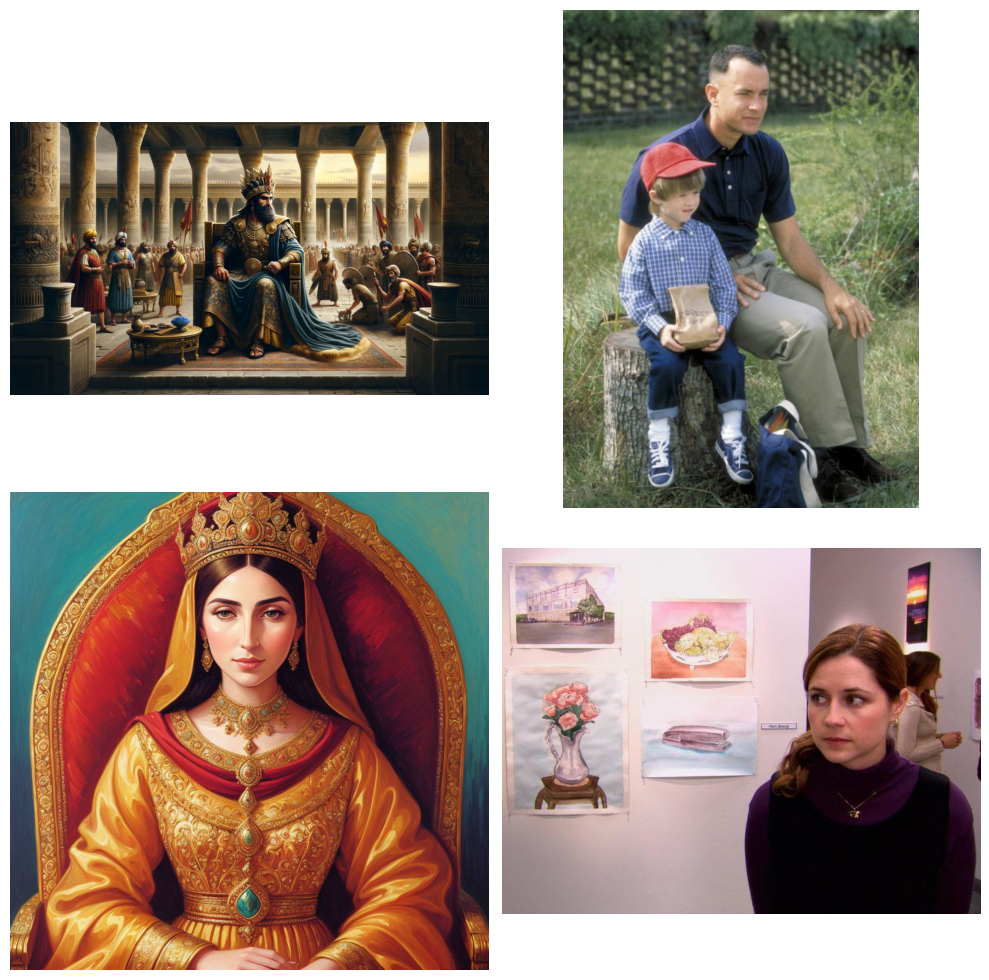

In [ ]:
# images visualization

import os
import matplotlib.pyplot as plt

os.chdir('/content/drive/My Drive/NLP_CA2')

img = Image.open()

image_filenames = ['Image1.jpg', 'Image2.jpg', 'Image3.jpg', 'Image4.jpg']


fig, axs = plt.subplots(2, 2, figsize=(10, 10))


for i, img_file in enumerate(image_filenames):
    img = Image.open(img_file)
    ax = axs[i // 2, i % 2]
    ax.imshow(img)
    ax.axis('off')


plt.tight_layout()
plt.show()

In [ ]:
# images' emneddings

image1_embed = get_image_embedding('Image1.jpg')
image2_embed = get_image_embedding('Image2.jpg')
image3_embed = get_image_embedding('Image3.jpg')
image4_embed = get_image_embedding('Image4.jpg')

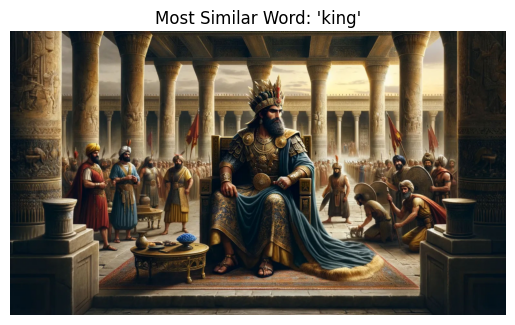

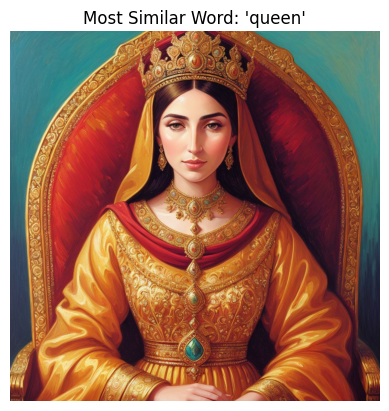

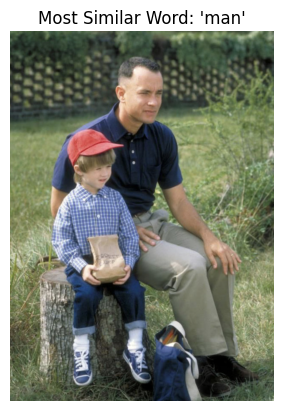

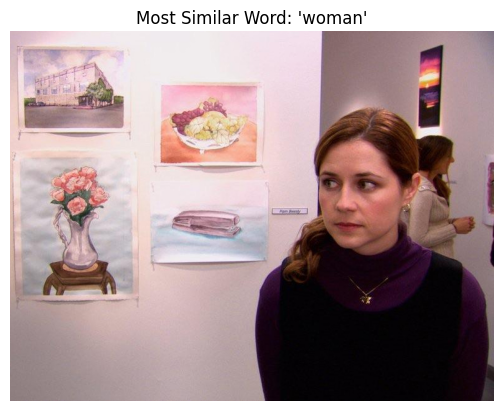

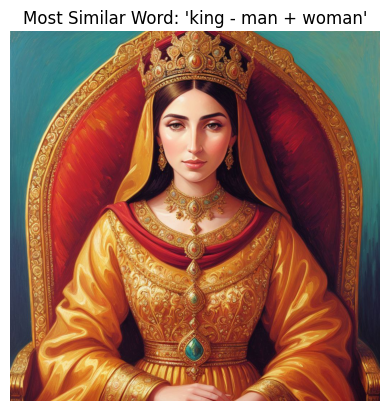

In [ ]:
words = {'king':king_embed, 'queen':queen_embed, 'man':man_embed, 'woman':woman_embed, 'king - man + woman':result_embed}
images = {'Image1':image1_embed, 'Image2':image2_embed, 'Image3':image3_embed, 'Image4':image4_embed}

for w, k in words.items():
  similarity = {}
  for i, j in images.items():
    similarity[(w,i)] = cosine_similarity(k, j)

  most_similar_pair = max(similarity, key=similarity.get)
  most_similar_word, most_similar_image  = most_similar_pair

  image_path = f"{most_similar_image}.jpg"
  img = Image.open(image_path)
  plt.imshow(img)
  plt.title(f"Most Similar Word: '{most_similar_word}'")
  plt.axis('off')
  plt.show()

## *بخش دوم*

###  الف

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
 Manوwoman  در فضای embedding به هم نزدیک هستند که نشان‌دهنده شباهت معنایی این دو کلمه در چارچوب جنسیت است.
<br>
 به طور مشابه، brother  و  sisterنیز به‌عنوان مفاهیم مرتبط با جنسیت و خویشاوندی در یک گروه نزدیک قرار گرفته‌اند.
 <br>
 aunt و  uncleنیز به یکدیگر نزدیک هستند، که نمایانگر رابطه نزدیک خویشاوندی این دو کلمه است.
<br>
 Kingو  queenدر این فضای دوبعدی در کنار هم قرار گرفته‌اند و در فاصله‌ای دورتر از سایر کلمات هستند، که نشان‌دهنده تفاوت جایگاه و مقام این دو کلمه با سایر کلمات است. این نزدیکی به مفهوم جایگاه درباری این کلمات مرتبط است.
<br>
 نزدیکی  brother و  sister با man و woman نشان‌دهنده نوعی ارتباط خانوادگی است، که در عین حال از مقام‌های رسمی مانند king و queen فاصله دارد.
<br>
کلمات مرتبط با خویشاوندی مانند  aunt و  uncleدر قسمت پایین نمودار و نزدیک به هم قرار دارند. این نشان می‌دهد که این کلمات از نظر معنایی به یکدیگر نزدیک‌اند و به نسبت نزدیک سایر روابط خویشاوندی هستند و از مقام‌های رسمی مانند king و queen فاصله دارند.


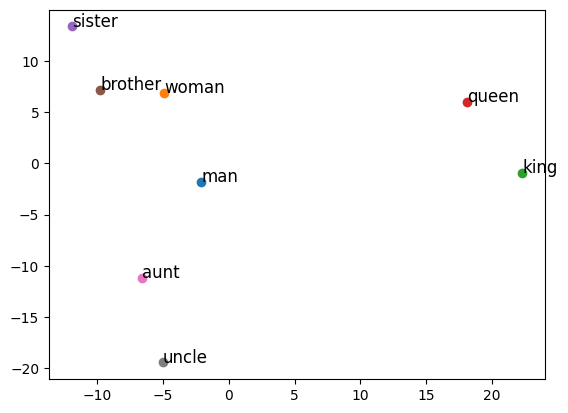

In [ ]:
#write your code here
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

king_embed = get_text_embedding('king')
queen_embed = get_text_embedding('queen')
man_embed = get_text_embedding('man')
woman_embed = get_text_embedding('woman')
sister_embed = get_text_embedding('sister')
brother_embed = get_text_embedding('brother')
aunt_embed = get_text_embedding('aunt')
uncle_embed = get_text_embedding('uncle')


embeddings = {
    'man': man_embed,
    'woman': woman_embed,
    'king': king_embed,
    'queen': queen_embed,
    'sister': sister_embed,
    'brother': brother_embed,
    'aunt': aunt_embed,
    'uncle': uncle_embed
}

word_list = list(embeddings.keys())
embedding_matrix = np.array([embeddings[word] for word in word_list])

scaler = StandardScaler()
embedding_matrix = scaler.fit_transform(embedding_matrix)
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embedding_matrix)


plt.figure()
for i, word in enumerate(word_list):
    x, y = reduced_embeddings[i]
    plt.scatter(x, y, label=word)
    plt.text(x + 0.02, y + 0.02, word, fontsize=12)

### ب

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
  "man" - "woman" و " brother" - " sister" : این دو جفت بردارهای مشابه و موازی دارند که نشان‌دهنده یک رابطه معنایی مشابه است. در اینجا تفاوت جنسیتی در نقش‌های مردانه و زنانه نمایان می‌شود.
 <br>
"brother" - "sister" : این جفت از نظر بردار و فاصله به جفت‌های "man - woman" و "aunt - uncle" شباهت دارد و تقریبا با آنها موازی است. این ارتباط  روابط خویشاوندی را نمایش می‌دهد.
<br>
 بردار "king - queen" از سایر جفت‌ها دورتر و به سمت راست نمودار متمایل است، که نشان می‌دهد این جفت به مفاهیم مقام پادشاهی و تفاوت قدرت اشاره دارد. در حالی که سایر جفت‌ها بیشتر به مفاهیم روزمره خویشاوندی نزدیک‌تر هستند.
<br>
در تمام بردارها جنسیت مونث بالاتر از جنسیت مذکر قرار دارد.


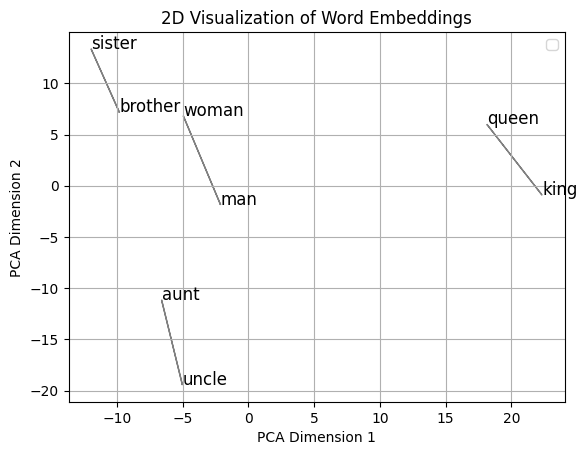

In [ ]:
#write your code here
pairs = [('woman', 'man'), ('king', 'queen'), ('sister', 'brother'), ('aunt', 'uncle')]

plt.figure()

for i, word in enumerate(word_list):
    x, y = reduced_embeddings[i]
    plt.text(x + 0.02, y + 0.02, word, fontsize=12)

for w1, w2 in pairs:
    idx1, idx2 = word_list.index(w1), word_list.index(w2)
    x1, y1 = reduced_embeddings[idx1]
    x2, y2 = reduced_embeddings[idx2]
    plt.arrow(x1, y1, x2 - x1, y2 - y1, color='gray', head_width=0.05, length_includes_head=True)

plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.title("2D Visualization of Word Embeddings")
plt.legend()
plt.grid(True)
plt.show()

## *بخش سوم*

توضیحات خود را اینجا بنویسید
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
واژه‌های "man" و "woman" به لحاظ موقعیت فضایی نزدیک به یکدیگر قرار گرفته‌اند، که نشان می‌دهد مدل تفاوت اصلی جنسیتی میان این دو مفهوم را درک کرده است.
<br>
کلمات "officer" و "carpenter" به کلمه "man" نزدیک‌تر هستند، در حالی که کلمات "nurse" و "homemaker" به کلمه "woman" نزدیک‌تر هستند. این فاصله‌ها نشان می‌دهند که مدل، حرفه‌های خاصی را بیشتر با مردان و برخی دیگر را بیشتر با زنان مرتبط می‌داند.
<br>
این مدل دارای سوگیری جنسیتی است، زیرا حرفه‌ها را با جنسیت‌های خاصی مرتبط کرده است. این سوگیری می‌تواند نتیجه داده‌های آموزشی باشد که این مدل بر اساس آن‌ها یاد گرفته است. اگر داده‌ها حاوی سوگیری‌های اجتماعی باشند، مدل نیز این سوگیری‌ها را به صورت یاد می‌گیرد و در بردارهای خود منعکس می‌کند
<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<br>
برای کاهش سوگیری جنسیتی در مدل‌های می‌توان از روش‌های زیر استفاده کرد:
<br>
استفاده از روش‌های کاهش سوگیری در embedding‌ها: می‌توان از تکنیک‌هایی مانند حذف بردارهای مرتبط با جنسیت استفاده کرد، به طوری که حرفه‌ها با جنسیت خاصی همبسته نشوند.
<br>
آموزش دوباره با داده‌های متوازن‌تر: آموزش مدل‌ها بر روی داده‌هایی که حرفه‌ها را به جنسیت‌های خاص مرتبط نمی‌کنند، می‌تواند به کاهش سوگیری کمک کند.

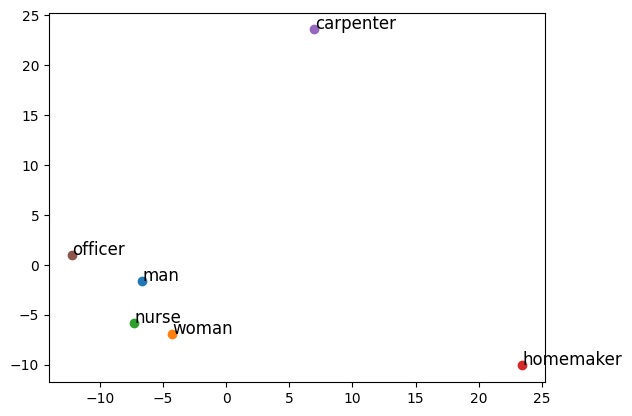

In [ ]:
#write your code here
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

man_embed = get_text_embedding('man')
woman_embed = get_text_embedding('woman')
nurse_embed = get_text_embedding('nurse')
homemaker_embed = get_text_embedding('homemaker')
carpeter_embed = get_text_embedding('carpenter')
officer_embed = get_text_embedding('officer')


embeddings = {
    'man': man_embed,
    'woman': woman_embed,
    'nurse': nurse_embed,
    'homemaker': homemaker_embed,
    'carpenter': carpeter_embed,
    'officer': officer_embed
}

word_list = list(embeddings.keys())
embedding_matrix = np.array([embeddings[word] for word in word_list])


scaler = StandardScaler()
embedding_matrix = scaler.fit_transform(embedding_matrix)
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embedding_matrix)


plt.figure()
for i, word in enumerate(word_list):
    x, y = reduced_embeddings[i]
    plt.scatter(x, y, label=word)
    plt.text(x + 0.02, y + 0.02, word, fontsize=12)
